# Garmin Training Analysis

Analysis of running performance and recovery metrics using Garmin data.

The analysis combines activity, HRV and sleep data stored in SQLite.

---

## 1. Setup

In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
DB_PATH = "../data/garmin.db"
conn = sqlite3.connect(DB_PATH)

---
## 2. Load Data

### Running activities

In [16]:
query = """
SELECT *
FROM running
ORDER BY date;
"""
running = pd.read_sql_query(query, conn)
running.head()

,id,date,distance,pace,vo2,avg_hr,max_hr,cadence,stride_length
0,17707560278,2024-12-07,8.01,5.88,47.0,160.0,180.0,79.0,106.81
1,17731797314,2024-12-10,1.29,7.11,48.0,140.0,163.0,70.0,97.81
2,17740040161,2024-12-11,6.02,6.52,49.0,128.0,146.0,75.0,102.23
3,17757614013,2024-12-14,7.29,6.88,49.0,137.0,165.0,74.0,96.83
4,17775036404,2024-12-16,4.30,7.00,49.0,149.0,167.0,75.0,94.10


### HRV

In [17]:
query = """
SELECT *
FROM hrv
ORDER BY date;
"""
hrv = pd.read_sql_query(query, conn)
hrv.head()

,date,value,baseline_upper,baseline_lower,status,percentage
0,2025-09-18,61,0,0,ONBOARDING,0
1,2025-09-19,62,1,-1,ONBOARDING,75
2,2025-09-20,53,64,59,ONBOARDING,0
3,2025-09-21,52,70,47,ONBOARDING,22
4,2025-09-22,52,69,45,ONBOARDING,29


### Sleep

In [18]:
query = """
SELECT *
FROM sleep
ORDER BY date;
"""
sleep = pd.read_sql_query(query, conn)
sleep.head()

,date,stress,score
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,2024-12-06,3.5,99.0


---

## 3. Data Quality

### Running missing values

In [19]:
running.isna().sum()

id                0
date              0
distance          0
pace              1
vo2              20
avg_hr            0
max_hr            0
cadence           0
stride_length     1
dtype: int64

### HRV missing values

In [20]:
hrv.isna().sum()

date              0
value             0
baseline_upper    0
baseline_lower    0
status            0
percentage        0
dtype: int64

### Sleep missing values

In [21]:
sleep.isna().sum()

date      4
stress    4
score     4
dtype: int64

---

## 4. Running Performance

### Pace over time

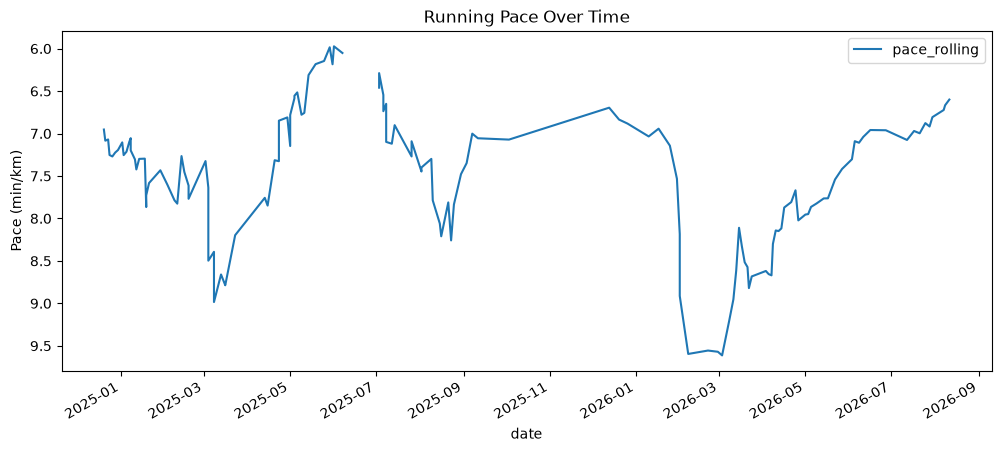

In [22]:
running["date"] = pd.to_datetime(running["date"])

running["pace_rolling"] = (
    running["pace"]
    .rolling(7)
    .mean()
)

running.plot(
    x="date",
    y="pace_rolling",
    figsize=(12, 5),
    title="Running Pace Over Time"
)

plt.gca().invert_yaxis()
plt.ylabel("Pace (min/km)")
plt.show()

### VO2 Max over time

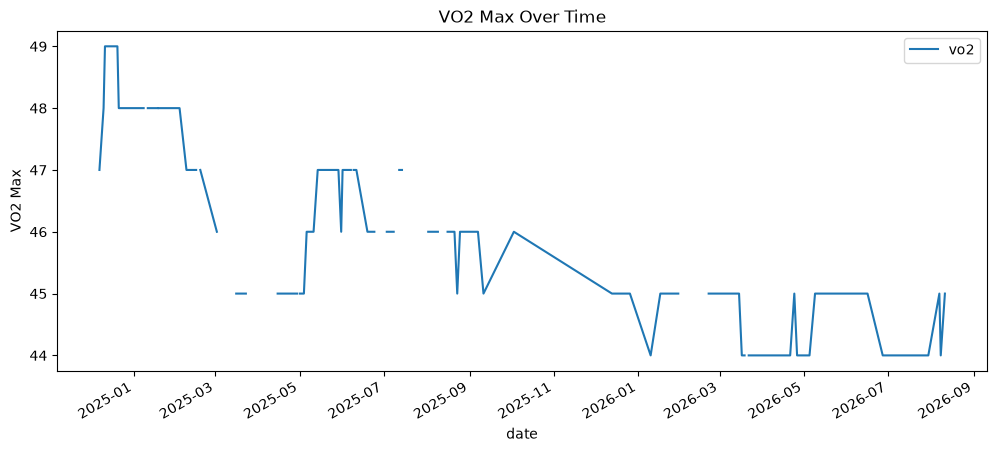

In [23]:
running.plot(
    x="date",
    y="vo2",
    figsize=(12, 5),
    title="VO2 Max Over Time"
)
plt.ylabel("VO2 Max")
plt.show()

---

## 5. Running Performance Relationships

### Heart Rate



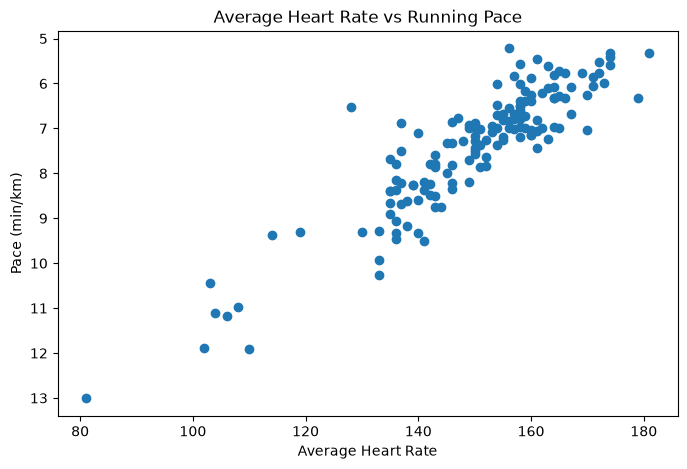

,avg_hr,pace
avg_hr,1.000000,-0.901973
pace,-0.901973,1.000000


In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(
    running["avg_hr"],
    running["pace"]
)
plt.gca().invert_yaxis()
plt.xlabel("Average Heart Rate")
plt.ylabel("Pace (min/km)")
plt.title("Average Heart Rate vs Running Pace")
plt.show()
running[["avg_hr", "pace"]].corr()

### Cadence

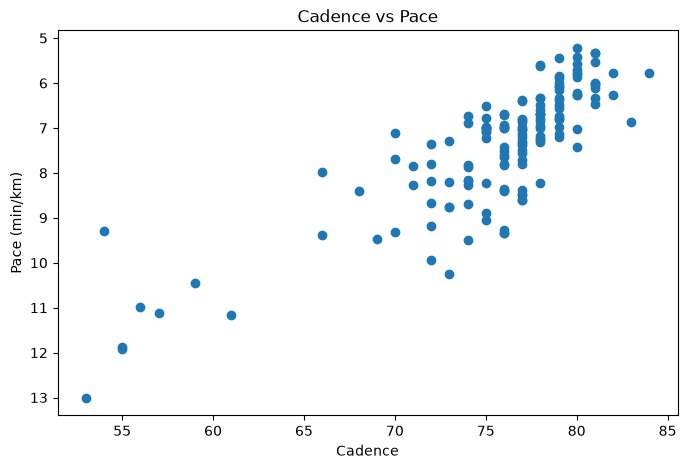

,cadence,pace
cadence,1.000000,-0.825086
pace,-0.825086,1.000000


In [25]:
plt.figure(figsize=(8,5))

plt.scatter(
    running["cadence"],
    running["pace"]
)

plt.xlabel("Cadence")
plt.ylabel("Pace (min/km)")
plt.title("Cadence vs Pace")

plt.gca().invert_yaxis()

plt.show()

running[["cadence", "pace"]].corr()

### Stride Length


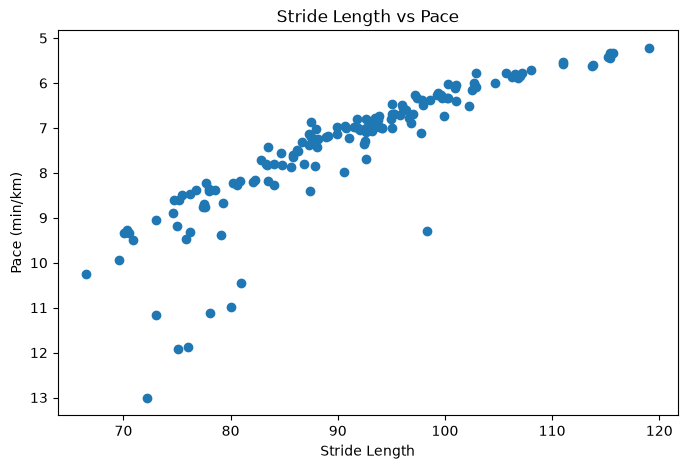

,stride_length,pace
stride_length,1.000000,-0.866977
pace,-0.866977,1.000000


In [26]:
plt.figure(figsize=(8,5))

plt.scatter(
    running["stride_length"],
    running["pace"]
)

plt.xlabel("Stride Length")
plt.ylabel("Pace (min/km)")
plt.title("Stride Length vs Pace")

plt.gca().invert_yaxis()

plt.show()

running[["stride_length", "pace"]].corr()

---

## 5. Recovery Relationships

### Stress vs HRV

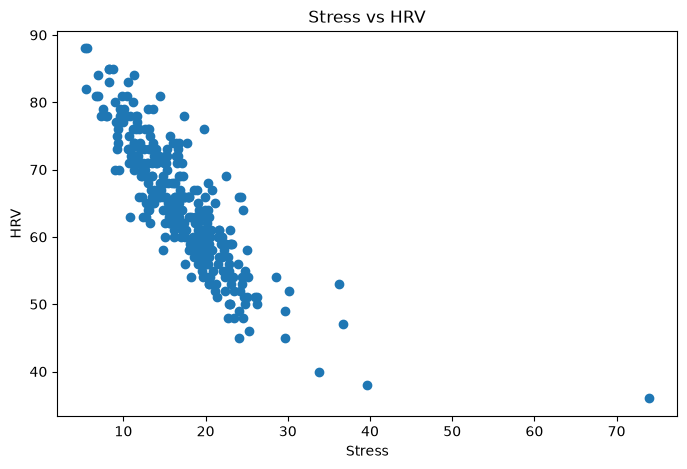

,stress,value
stress,1.000000,-0.812212
value,-0.812212,1.000000


In [27]:
hrv_sleep = hrv.merge(
    sleep[["date", "stress"]],
    on="date",
    how="left"
)

plt.figure(figsize=(8,5))

plt.scatter(
    hrv_sleep["stress"],
    hrv_sleep["value"]
)

plt.xlabel("Stress")
plt.ylabel("HRV")
plt.title("Stress vs HRV")

plt.show()
hrv_sleep[["stress", "value"]].corr()

---

## 8. Key Findings

Based on the analysis above:

- **Running pace and heart rate:** Running pace shows a very strong negative correlation with average heart rate (r = -0.902), indicating that faster runs are strongly associated with higher cardiovascular intensity.

- **Running mechanics:** Running pace also shows strong negative correlations with stride length (r = -0.867) and cadence (r = -0.825). This suggests that faster runs are associated with both longer strides and higher cadence.

- **VO2 Max:** VO2 Max is monitored over time as an indicator of aerobic fitness. However, missing values limit the strength of conclusions about its long-term trend.

- **Stress and HRV:** HRV shows a strong negative correlation with stress (r = -0.812). Higher stress levels are associated with lower HRV values in this dataset.

- **Sleep:** Sleep data provides an additional recovery metric, although the current analysis does not establish a clear relationship between sleep score and running performance.

---

## 9. Limitations

* The dataset represents data from a single athlete.
* Garmin measurements may contain missing or inconsistent values.
* Correlation does not imply causation.
* The analysis does not account for all factors that can affect running performance.

---

## 10. Close Database Connection

In [28]:
conn.close()